In [1]:
from lignin_saf.ligsaf_chemicals import create_chemicals
from lignin_saf.ligsaf_settings import feed_parameters, prices
from lignin_saf.ligsaf_system import create_rcf_system
from lignin_saf.ligsaf_purification_system import create_rcf_oil_purification_system
from lignin_saf.monomer_purification import create_monomer_purification_system
from lignin_saf.ligsaf_utilities_system import create_rcf_utilities_system
from biorefineries import cellulosic
from cellulosic_tea import create_cellulosic_ethanol_tea
from biosteam import main_flowsheet as F
import biosteam as bst
import thermosteam as tmo
bst.nbtutorial()

In [2]:
# Code just to increase the number of display units for the various components
tmo.Stream.display_units.N = 40       # Increasing number of display units to see all components of streams 
tmo.MultiStream.display_units.N = 40  
bst.Stream.display_units.N = 40       # Increasing number of display units to see all components of streams 
bst.MultiStream.display_units.N = 40  

In [3]:
chems = create_chemicals()
bst.settings.set_thermo(chems)
bst.settings.CEPCI = 541.7   # 2016 USD basis

# Poplar group must be defined before creating any stream that references it
chems.define_group(
    name='Poplar',
    IDs=['Glucan', 'Xylan', 'Arabinan', 'Mannan', 'Galactan',
         'Sucrose', 'Lignin', 'Acetate', 'Extract', 'Ash'],
    composition=[0.464, 0.134, 0.002, 0.037, 0.014,
                 0.001, 0.285, 0.035, 0.016, 0.012],
    wt=True
)

poplar_in = bst.Stream('Poplar_In',
                       Poplar=feed_parameters['flow'] * 1e3,
                       Water=feed_parameters['moisture'] * feed_parameters['flow'] * 1e3,
                       phase='l', units='kg/d', price = prices['Feedstock'])



In [4]:
rcf_system = create_rcf_system(ins=poplar_in)
rcf_system.simulate()



In [5]:
rcf_oil_purification_sys = create_rcf_oil_purification_system(ins=F.RCF_Oil)


In [6]:
monomer_purification_sys = create_monomer_purification_system(ins=F.Purified_RCF_Oil)

In [7]:
rcf_oil_purification_sys.simulate()
monomer_purification_sys.simulate()

In [8]:
BT, WWT, gas_mixer = create_rcf_utilities_system()

In [9]:
'''
BT = bst.facilities.BoilerTurbogenerator(fuel_price = 0.2612)
WWT = bst.create_conventional_wastewater_treatment_system(
        'WWT',
        ins=(F.WW_10, 
             F.WastePulp, 
             F.RCF_WW, 
             F.WW_11, 
             F.WW_12
              ),
    )
'''

"\nBT = bst.facilities.BoilerTurbogenerator(fuel_price = 0.2612)\nWWT = bst.create_conventional_wastewater_treatment_system(\n        'WWT',\n        ins=(F.WW_10, \n             F.WastePulp, \n             F.RCF_WW, \n             F.WW_11, \n             F.WW_12\n              ),\n    )\n"

In [10]:
#BT.ins[0] = WWT.outs[1]
#gas_mixer = bst.Mixer('MIX_BT_gas', ins=(F.Purge_Light_Gases, WWT.outs[0]))
#BT.ins[1] = gas_mixer.outs[0]


In [11]:
#etoh_system = cellulosic.create_cellulosic_ethanol_system(ins = F.Carbohydrate_Pulp)
#etoh_system.simulate()

In [12]:
#for unit in WWT.units:
#    if hasattr(unit, 'strict_moisture_content'):
#        unit.strict_moisture_content = False

In [13]:
rcf_combined_system = bst.System(
    'Combined_RCF_System',
    path=(rcf_system, 
          rcf_oil_purification_sys, 
          monomer_purification_sys, 
          WWT),
    facilities=[gas_mixer, BT],
)

In [14]:
rcf_combined_system.simulate()

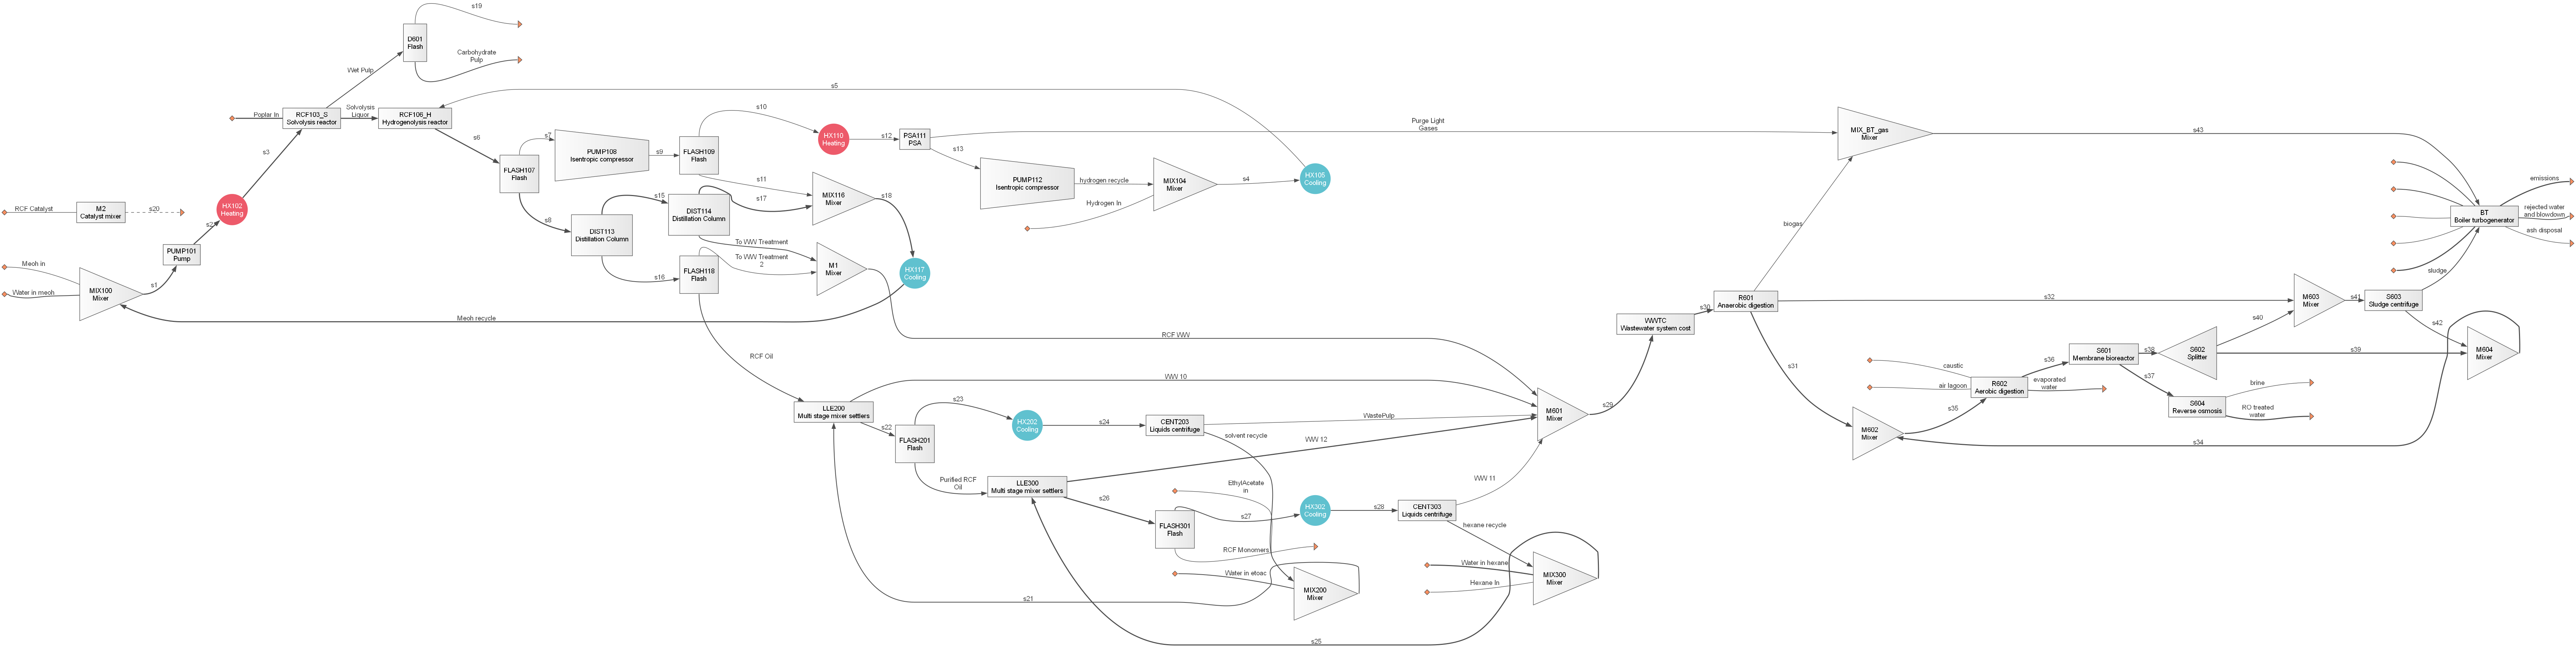

In [15]:
rcf_combined_system.diagram(format = 'png')

In [16]:
operators_per_section = 1  # operators per section from Seider recommendation
num_process_sections = 3  # number of proces sections from Seider recommendation [2 reactor, 1 separation]
num_operators_per_shift = operators_per_section * num_process_sections * 1  # multiplied by 2 for large continuous flow process (e.g., 1000 ton/day product). from Seider pg 505
num_shifts = 5  # number of shifts
pay_rate = 40  # $/hr
DWandB = num_operators_per_shift * num_shifts * 2080 * pay_rate  # direct wages and benefits. DWandB [$/year] = (operators/shift)*(5 shifts)*(40 hr/week)*(operating days/year-operator)*($/hr)
Dsalaries_benefits = 0.15 * DWandB  # direct salaries and benefits from Seider
O_supplies = 0.06 * DWandB  # Operating supplies and services from Seider
technical_assistance = 5 * 75000  # $/year. Technical assistance to manufacturing. assume 5 workers at $75000/year
control_lab = 5 * 80000  # $/year. Control laboratory. assume 5 workers at $80000/year
labor = DWandB + Dsalaries_benefits + O_supplies + technical_assistance + control_lab 

In [17]:
F.Carbohydrate_Pulp.price = prices['Feedstock']

In [18]:
integrated_tea = create_cellulosic_ethanol_tea(rcf_combined_system)

In [19]:
integrated_tea.labor_cost = labor

In [20]:
print(f'The MSP for RCF monomers is  {round(integrated_tea.solve_price(F.RCF_Monomers),3)} USD/kg')

The MSP for RCF monomers is  6.787 USD/kg


In [21]:
print('CAPEX', round(rcf_combined_system.installed_equipment_cost / 1e6, 2), 'MMUSD')
print('OPEX', round((rcf_combined_system.material_cost + rcf_combined_system.utility_cost) / 1e6, 3), 'MMUSD/yr')



CAPEX 278.9 MMUSD
OPEX 244.014 MMUSD/yr


In [22]:
rcf_oil_purification_sys.diagram()

In [23]:
F.EthylAcetate_in.price

3.4937185929648242

In [24]:
rcf_system.diagram()

In [25]:
rcf_combined_system

System: Combined_RCF_System
Highest convergence error among components in recycle
streams {HX117-0, PUMP112-0} after 1 loops:
- flow rate   1.57e-08 kmol/hr (0.017%)
- temperature 2.35e-03 K (0.00076%)
ins...
[0] RCF_Catalyst  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): NiC  2.28
[1] air_lagoon  
    phase: 'g', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): N2  430
                    O2  106
[2] caustic  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Water  58
                    NaOH   26.1
[3] Poplar_In  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Water     925
                    Sucrose   0.243
                    Extract   7.4
                    Acetate   48.6
                    Ash       1e+03
                    Lignin    156
                    Glucan    238
                    Xylan     84.5
                    Arabinan  1.26
                    Mannan    19
                    Galactan  7.2
[4] Meoh_in  
    phase: 'l',